<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801SL_Assignment2_Q2_2_Philine_Potgieter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Improrting Libraries



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from IPython.display import Markdown, display

In [2]:
mode2 = pd.read_excel('/content/sample_data/mode2.xlsx')

In [3]:
mode2.head()

,The SAS System,Unnamed: 1
0,NaN,NaN
1,X1,X2
2,107.705,95.795
3,85.02,235.536
4,154.556,125.419


In [4]:
mode2.count()

,0
The SAS System,1501
Unnamed: 1,1501


##Question 1 a) Data visualization

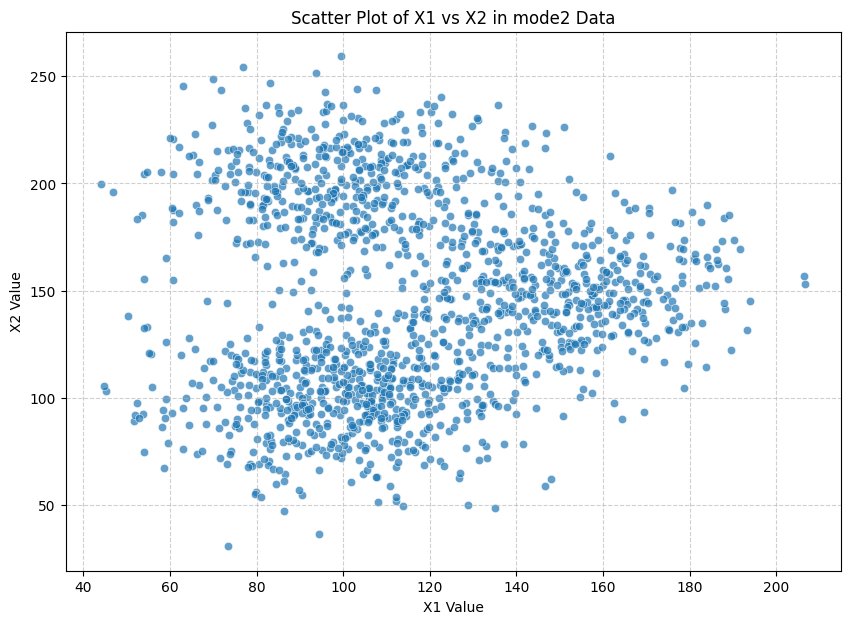

In [5]:
raw_mode2_df = pd.read_excel('/content/sample_data/mode2.xlsx')


mode2_scatter_plot = raw_mode2_df.iloc[2:].copy()
mode2_scatter_plot.columns = raw_mode2_df.iloc[1]

mode2_scatter_plot['X1'] = pd.to_numeric(mode2_scatter_plot['X1'])
mode2_scatter_plot['X2'] = pd.to_numeric(mode2_scatter_plot['X2'])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=mode2_scatter_plot, x='X1', y='X2', alpha=0.7)
plt.title('Scatter Plot of X1 vs X2 in mode2 Data')
plt.xlabel('X1 Value')
plt.ylabel('X2 Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##Question 1 b) Gaussian Mixture model with nr of cluster scenarios to find the best model

In [6]:
raw_mode2_df = pd.read_excel('/content/sample_data/mode2.xlsx')

mode2_data_for_gmm = raw_mode2_df.iloc[2:].copy()
mode2_data_for_gmm.columns = raw_mode2_df.iloc[1]

mode2_data_for_gmm['X1'] = pd.to_numeric(mode2_data_for_gmm['X1'])
mode2_data_for_gmm['X2'] = pd.to_numeric(mode2_data_for_gmm['X2'])

X = mode2_data_for_gmm[['X1', 'X2']]

n_components_list = [2, 5, 10, 15, 20, 30, 40]

results = []

for n_components in n_components_list:
    start_time = time.time()

    gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm.fit(X)

    end_time = time.time()
    runtime = end_time - start_time

    aic = gmm.aic(X)
    bic = gmm.bic(X)

    results.append({
        'n_components': n_components,
        'Runtime (s)': runtime,
        'AIC': aic,
        'BIC': bic
    })


results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

|   n_components |   Runtime (s) |     AIC |     BIC |
|---------------:|--------------:|--------:|--------:|
|              2 |      0.157866 | 29640.5 | 29699   |
|              5 |      0.243936 | 29435.9 | 29590   |
|             10 |      0.42948  | 29480.6 | 29794.1 |
|             15 |      0.635424 | 29519.9 | 29992.7 |
|             20 |      0.81976  | 29544.5 | 30176.7 |
|             30 |      3.2583   | 29605   | 30556   |
|             40 |      2.38998  | 29615.1 | 30885   |


## Question 2 c) Best model & cluster characteristics

In [7]:
optimal_n_components = 5

gmm_optimal = GaussianMixture(n_components=optimal_n_components, random_state=42, n_init=10)
gmm_optimal.fit(X)

for i, mean in enumerate(gmm_optimal.means_):
    print(f"    Cluster {i}: {mean}")


for i, cov in enumerate(gmm_optimal.covariances_):
    print(f"    Cluster {i}:\n{cov}")

cluster_labels = gmm_optimal.predict(X)

cluster_counts = []
for i in range(gmm_optimal.n_components):
    count = np.sum(cluster_labels == i)
    cluster_counts.append({'Cluster': i, 'Count': count})
    print(f"  Cluster {i}: {count} data points")

    Cluster 0: [110.44103425 106.06472226]
    Cluster 1: [107.9063389  214.10336538]
    Cluster 2: [151.37410749 149.41580845]
    Cluster 3: [ 93.81123255 189.94502619]
    Cluster 4: [87.67659354 95.48178788]
    Cluster 0:
[[241.3100391  -43.5380463 ]
 [-43.5380463  358.25169357]]
    Cluster 1:
[[387.61850378 -89.5824983 ]
 [-89.5824983  249.18367709]]
    Cluster 2:
[[366.73234426  19.17805308]
 [ 19.17805308 412.51288286]]
    Cluster 3:
[[330.09762257 -86.733601  ]
 [-86.733601   251.20079676]]
    Cluster 4:
[[289.66573524 -74.47009623]
 [-74.47009623 443.36661042]]
  Cluster 0: 347 data points
  Cluster 1: 192 data points
  Cluster 2: 435 data points
  Cluster 3: 265 data points
  Cluster 4: 261 data points


In [8]:
cluster_comparison_data = []

for i in range(optimal_n_components):

    mean_x1 = gmm_optimal.means_[i][0]
    mean_x2 = gmm_optimal.means_[i][1]

    cov_matrix = gmm_optimal.covariances_[i]
    var_x1 = cov_matrix[0, 0]
    var_x2 = cov_matrix[1, 1]
    cov_x1x2 = cov_matrix[0, 1]

    cluster_comparison_data.append({
        'Cluster': i,
        'Data Points': cluster_counts[i]['Count'],
        'Weight': gmm_optimal.weights_[i],
        'Mean_X1': mean_x1,
        'Mean_X2': mean_x2,
        'Var_X1': var_x1,
        'Var_X2': var_x2,
        'Cov_X1X2': cov_x1x2
    })

comparison_df = pd.DataFrame(cluster_comparison_data)

display(Markdown(f"**--- Cluster Characteristics Comparison Table ({optimal_n_components}-Components GMM) ---**"))
display(Markdown(comparison_df.to_markdown(index=False)))

**--- Cluster Characteristics Comparison Table (5-Components GMM) ---**

|   Cluster |   Data Points |   Weight |   Mean_X1 |   Mean_X2 |   Var_X1 |   Var_X2 |   Cov_X1X2 |
|----------:|--------------:|---------:|----------:|----------:|---------:|---------:|-----------:|
|         0 |           347 | 0.218038 |  110.441  |  106.065  |  241.31  |  358.252 |   -43.538  |
|         1 |           192 | 0.133977 |  107.906  |  214.103  |  387.619 |  249.184 |   -89.5825 |
|         2 |           435 | 0.28774  |  151.374  |  149.416  |  366.732 |  412.513 |    19.1781 |
|         3 |           265 | 0.172772 |   93.8112 |  189.945  |  330.098 |  251.201 |   -86.7336 |
|         4 |           261 | 0.187473 |   87.6766 |   95.4818 |  289.666 |  443.367 |   -74.4701 |

/tmp/ipykernel_646/1377718814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Data Points', data=comparison_df, palette='viridis')


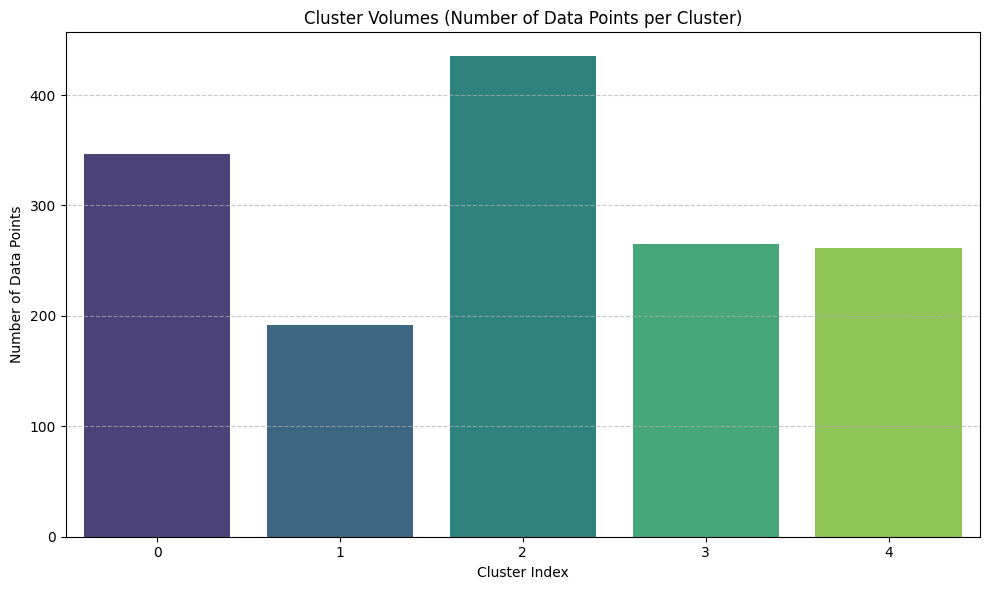

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Data Points', data=comparison_df, palette='viridis')
plt.title('Cluster Volumes (Number of Data Points per Cluster)')
plt.xlabel('Cluster Index')
plt.ylabel('Number of Data Points')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

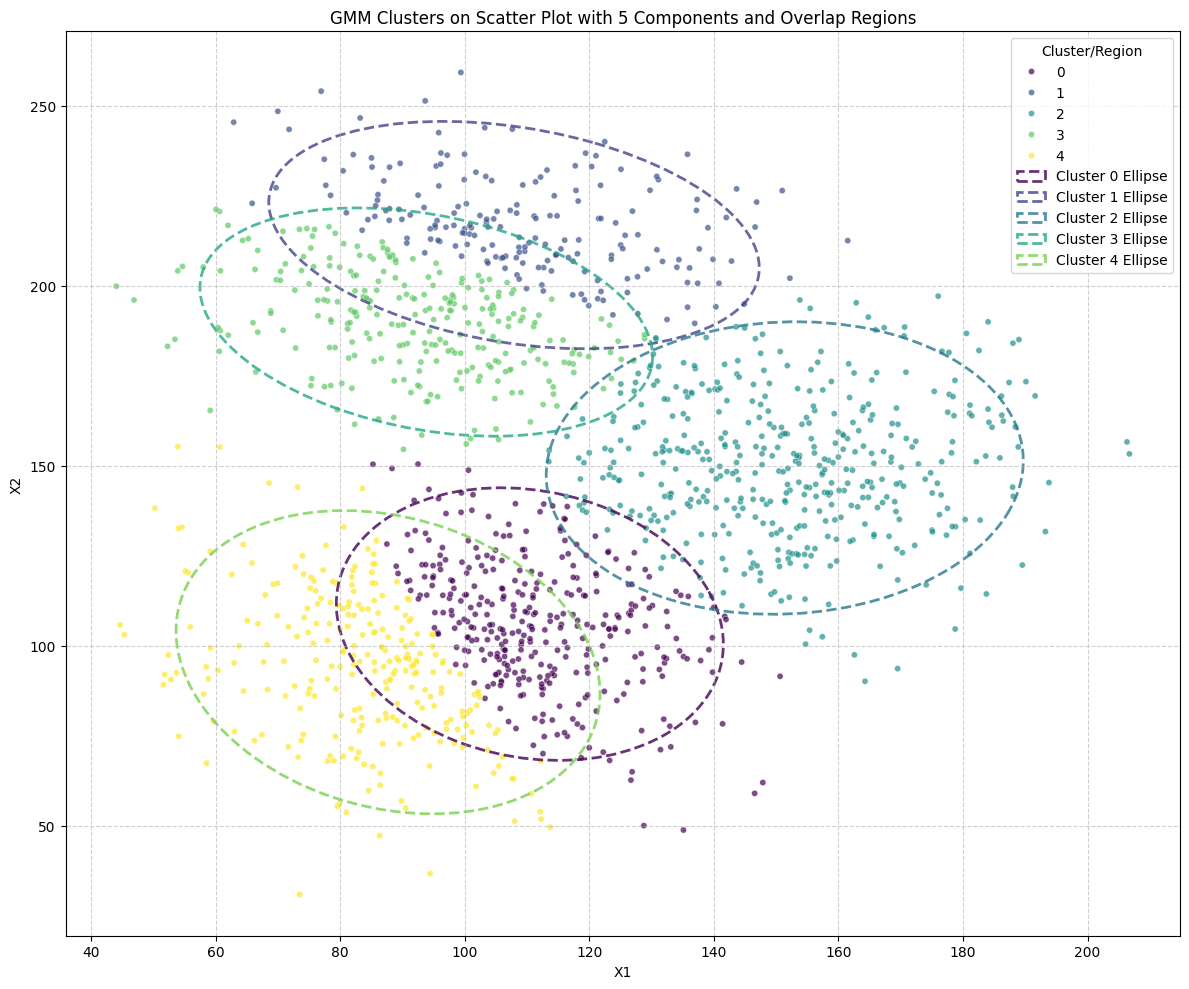

In [10]:
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 10))

sns.scatterplot(x=X['X1'], y=X['X2'], hue=cluster_labels, palette='viridis', s=20, alpha=0.7, legend='full')

ax = plt.gca()


for i in range(optimal_n_components):
    mean = gmm_optimal.means_[i]
    cov = gmm_optimal.covariances_[i]
    weight = gmm_optimal.weights_[i]


    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues) * 2

    ellipse = mpatches.Ellipse(xy=mean, width=width, height=height, angle=angle,
                               facecolor='none', edgecolor=plt.cm.viridis(i/optimal_n_components),
                               linestyle='--', linewidth=2, alpha=0.8, label=f'Cluster {i} Ellipse')
    ax.add_patch(ellipse)

plt.title(f'GMM Clusters on Scatter Plot with {optimal_n_components} Components and Overlap Regions')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(title='Cluster/Region')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
optimal_results = results_df[results_df['n_components'] == optimal_n_components]
aic_optimal = optimal_results['AIC'].values[0]
bic_optimal = optimal_results['BIC'].values[0]

print(f"\n--- AIC for the {optimal_n_components}-Component GMM: {aic_optimal:.2f} ---")
print(f"--- BIC for the {optimal_n_components}-Component GMM: {bic_optimal:.2f} ---")


--- AIC for the 5-Component GMM: 29435.89 ---
--- BIC for the 5-Component GMM: 29589.98 ---


In [12]:
# Calculate and print the log-likelihood for the optimal GMM
log_likelihood = gmm_optimal.score(X) * len(X)
print(f"\n--- Log-Likelihood for {optimal_n_components}-Component GMM: {log_likelihood:.2f} ---")


--- Log-Likelihood for 5-Component GMM: -14688.95 ---


In [13]:
# Calculate and print the predictive likelihood (average log-likelihood per sample)
predictive_likelihood = gmm_optimal.score(X)
print(f"\n--- Predictive Likelihood (Avg. Log-Likelihood per Sample) for {optimal_n_components}-Component GMM: {predictive_likelihood:.2f} ---")


--- Predictive Likelihood (Avg. Log-Likelihood per Sample) for 5-Component GMM: -9.79 ---


In [14]:
# Calculate and print the Silhouette Score for the optimal GMM
silhouette_score_optimal = silhouette_score(X, gmm_optimal.predict(X))
print(f"\n--- Silhouette Score for {optimal_n_components}-Component GMM: {silhouette_score_optimal:.3f} ---")


--- Silhouette Score for 5-Component GMM: 0.338 ---


In [15]:
import numpy as np

def calculate_point_entropy_generalized(probabilities):
    entropy = 0
    for p in probabilities:
        if p > 0:
            entropy -= p * np.log2(p)
    return entropy

posterior_probabilities = gmm_optimal.predict_proba(X)

X_with_probs = X.copy()
prob_cols = []
for i in range(optimal_n_components):
    col_name = f'p_cluster_{i}'
    X_with_probs[col_name] = posterior_probabilities[:, i]
    prob_cols.append(col_name)

X_with_probs['entropy'] = X_with_probs[prob_cols].apply(calculate_point_entropy_generalized, axis=1)

average_entropy = X_with_probs['entropy'].mean()

print(f"\n--- Average Entropy of Posterior Probabilities for {optimal_n_components}-Component GMM: {average_entropy:.3f} ---")

display_cols = ['X1', 'X2'] + prob_cols + ['entropy']
display(X_with_probs[display_cols].head())


--- Average Entropy of Posterior Probabilities for 5-Component GMM: 0.595 ---


1,X1,X2,p_cluster_0,p_cluster_1,p_cluster_2,p_cluster_3,p_cluster_4,entropy
2,107.705,95.795,7.060094e-01,2.469969e-14,2.524319e-03,8.668433e-09,2.914663e-01,0.894773
3,85.020,235.536,3.061057e-10,9.332010e-01,7.672219e-07,6.679825e-02,4.343069e-10,0.353877
4,154.556,125.419,1.259739e-02,1.274433e-07,9.873180e-01,3.699125e-05,4.753244e-05,0.098909
5,119.904,194.497,1.497767e-05,5.245906e-01,3.527351e-02,4.401206e-01,2.968774e-07,1.179822
6,131.874,124.638,3.855351e-01,1.185506e-07,6.069838e-01,2.368023e-04,7.244121e-03,1.021681


In [16]:
from scipy.spatial.distance import mahalanobis

def calculate_average_mahalanobis_distance(X, gmm_optimal, cluster_labels):
    total_mahalanobis_distance = 0
    num_samples = len(X)

    inv_covariances = []
    for cov_matrix in gmm_optimal.covariances_:
        inv_covariances.append(np.linalg.inv(cov_matrix))

    for i in range(num_samples):
        point = X.iloc[i].values
        assigned_cluster = cluster_labels[i]
        cluster_mean = gmm_optimal.means_[assigned_cluster]
        cluster_inv_cov = inv_covariances[assigned_cluster]

        dist = mahalanobis(point, cluster_mean, cluster_inv_cov)
        total_mahalanobis_distance += dist

    return total_mahalanobis_distance / num_samples

# Calculate the average Mahalanobis distance
average_mahalanobis_dist = calculate_average_mahalanobis_distance(X, gmm_optimal, cluster_labels)
print(f"\n--- Average Mahalanobis Distance for {optimal_n_components}-Component GMM: {average_mahalanobis_dist:.3f} ---")


--- Average Mahalanobis Distance for 5-Component GMM: 1.128 ---
